In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install xlrd
from scipy.interpolate import interp1d
from scipy.interpolate import UnivariateSpline



In [8]:
df = pd.read_excel("sample1.xls")
print(df.head())

   Periodo       Fecha Pais  Unidad ptype  power    price OC  \
0        1  13/05/2025   MI     NaN     C  172.8  1500.00  O   
1        1  13/05/2025   MI     NaN     C  411.9  1500.00  O   
2        1  13/05/2025   MI     NaN     C    6.8  1500.00  O   
3        1  13/05/2025   MI     NaN     C    0.1   800.00  O   
4        1  13/05/2025   MI     NaN     C    0.1   700.05  O   

  Tipología de Oferta  
0                   S  
1                   S  
2                   S  
3                   S  
4                   S  


In [109]:
# 수요곡선 (계단형)
demand_func = interp1d(demand['price'], demand['Cumulative Energy'],
                       kind='previous', bounds_error=False,
                       fill_value=(demand['Cumulative Energy'].iloc[0], demand['Cumulative Energy'].iloc[-1]))

# 공급곡선 (계단형)
supply_func = interp1d(supply['price'], supply['Cumulative Energy'],
                       kind='previous', bounds_error=False,
                       fill_value=(supply['Cumulative Energy'].iloc[0], supply['Cumulative Energy'].iloc[-1]))

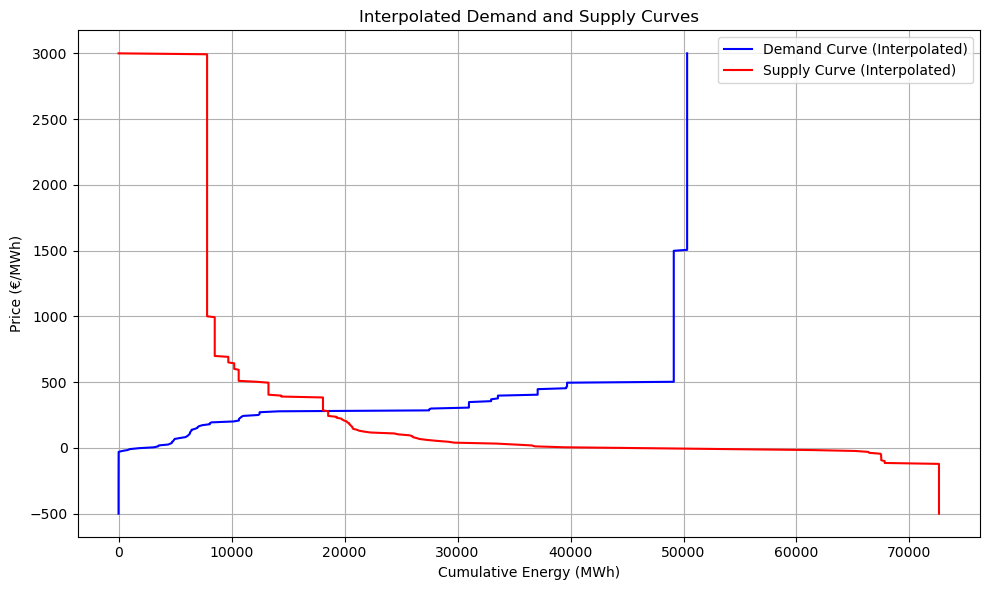

In [110]:
# 보간용 price grid 설정 (수요·공급 곡선이 정의된 price 범위 내에서)
price_grid = np.linspace(min(demand['price'].min(), supply['price'].min()),
                         max(demand['price'].max(), supply['price'].max()),
                         500)

# 함수 호출 (보간된 누적 전력량 계산)
demand_interp_vals = demand_func(price_grid)
supply_interp_vals = supply_func(price_grid)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(demand_interp_vals, price_grid, label='Demand Curve (Interpolated)', color='blue')
plt.plot(supply_interp_vals, price_grid, label='Supply Curve (Interpolated)', color='red')
plt.xlabel('Cumulative Energy (MWh)')
plt.ylabel('Price (€/MWh)')
plt.title('Interpolated Demand and Supply Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# === RDC 계산 함수 ===
def compute_rdc_from_curves(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []

    def demand_interp(p):
        return np.interp(p, price_grid, demand_vals)

    def supply_interp(p):
        return np.interp(p, price_grid, supply_vals)

    for q in wf_offers:
        def residual(p):
            return demand_interp(p) - supply_interp(p) - q

        try:
            sol = root_scalar(residual, bracket=[price_grid[0], price_grid[-1]], method='bisect')
            p_star = sol.root if sol.converged else None
        except:
            p_star = None

        rdc.append((q, p_star))

    return rdc

In [116]:
# === WF 입찰량 설정 ===
wf_offer_grid = np.linspace(0, 500, 30)

# === RDC 계산 ===
rdc_points = compute_rdc_from_curves(price_grid, demand_interp_vals, supply_interp_vals, wf_offer_grid)
rdc_points = [(q, p) for q, p in rdc_points if p is not None]  # None 제거
q_vals, p_vals = zip(*rdc_points)

# === 시각화 ===
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(q_vals, p_vals, marker='o', color='blue', label='Residual Demand Curve')
plt.plot(demand_interp_vals, price_grid, color='red', label='Demand Curve')
plt.plot(supply_interp_vals, price_grid, color='green', label='Supply Curve')
plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Supply, Demand, and Residual Demand Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

ValueError: not enough values to unpack (expected 2, got 0)

In [96]:
price_grid = np.linspace(10.1, 200, 5000)
demand_vals = demand_func(price_grid)
supply_vals = supply_func(price_grid)
wf_offers = np.linspace(0, 5000, 50)

rdc_points = compute_rdc_from_curves_fixed_bracket(price_grid, demand_vals, supply_vals, wf_offers)

filtered_rdc = [(q, p) for q, p in rdc_points if p is not None]
if filtered_rdc:
    q_vals, p_vals = zip(*filtered_rdc)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(q_vals, p_vals, label='RDC (fixed bracket)', color='black', marker='o')
    plt.xlabel("My Offer q (MW)")
    plt.ylabel("Clearing Price p* (€/MWh)")
    plt.title("Residual Demand Curve with Fixed Bracket")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("❗ No RDC points found — check bracket or q range.")


❗ No RDC points found — check bracket or q range.


In [95]:
# 기존 보간 데이터
# price_grid = ...
# demand_interp_vals = demand_func(price_grid)
# supply_interp_vals = supply_func(price_grid)

wf_offers = np.linspace(0, 5000, 50)

rdc_points = compute_rdc_from_curves_smart_bracket(price_grid, demand_interp_vals, supply_interp_vals, wf_offers)

filtered_rdc = [(q, p) for q, p in rdc_points if p is not None]
if filtered_rdc:
    q_vals, p_vals = zip(*filtered_rdc)
    # 시각화
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(q_vals, p_vals, label='RDC (Smart Interp)', color='black', marker='o')
    plt.xlabel("Quantity (MW)")
    plt.ylabel("Clearing Price (€/MWh)")
    plt.title("Residual Demand Curve (with interp arrays + smart bracket)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("❗ No valid RDC points found.")


NameError: name 'bracket' is not defined

In [78]:
# 설정
price_bounds = (price_grid[0], price_grid[-1])  # ex: (min_price, max_price)

# RDC 계산
rdc_points = compute_rdc_by_supply_injection(demand_func, supply_func, price_bounds, max_q=1000, step=100)

# 결과 정리
filtered_rdc = [(q, p) for q, p in rdc_points if p is not None]
q_vals, p_vals = zip(*filtered_rdc)

# 시각화 (필요 시)
plt.figure(figsize=(10,6))
plt.plot(q_vals, p_vals, label='Residual Demand Curve (direct method)', color='black', marker='o')
plt.xlabel("My Offer q (MW)")
plt.ylabel("Market Clearing Price p* (€/MWh)")
plt.title("Residual Demand Curve via Incremental Supply Injection")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


ValueError: not enough values to unpack (expected 2, got 0)

In [72]:
print("RDC 계산된 수:", len(rdc_points))
print("성공적으로 계산된 p* 수:", sum(p is not None for _, p in rdc_points))


RDC 계산된 수: 50
성공적으로 계산된 p* 수: 0


In [ ]:
q_vals, p_vals = zip(*[(q, p) for q, p in rdc_points if p is not None])


In [ ]:
# === 시각화 ===
plt.figure(figsize=(12, 7))

# 공급곡선
plt.plot(supply_vals, price_grid, label='Supply Curve (Interpolated)', color='red')
# 수요곡선
plt.plot(demand_vals, price_grid, label='Demand Curve (Interpolated)', color='blue')
# RDC
plt.plot(q_vals, p_vals, label='Residual Demand Curve (RDC)', color='black', linestyle='-', marker='o')

plt.xlabel("Cumulative Energy (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Supply / Demand Curves with RDC Overlay")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
# 에너지 기준 정렬 (x = 누적 에너지, y = 가격)
demand_sorted = demand.sort_values('Cumulative Energy')
supply_sorted = supply.sort_values('Cumulative Energy')

# LOWESS: x = Cumulative Energy, y = Price
demand_lowess = sm.nonparametric.lowess(
    endog=demand_sorted['price'],
    exog=demand_sorted['Cumulative Energy'],
    frac=0.1
)

supply_lowess = sm.nonparametric.lowess(
    endog=supply_sorted['price'],
    exog=supply_sorted['Cumulative Energy'],
    frac=0.1
)


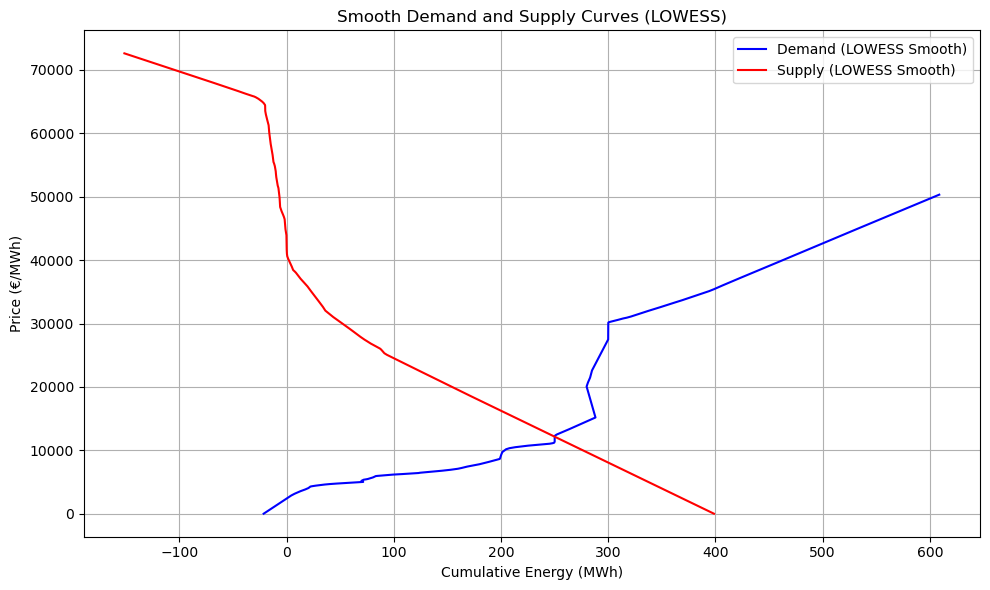

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(demand_lowess[:, 1], demand_lowess[:, 0], label='Demand (LOWESS Smooth)', color='blue')
plt.plot(supply_lowess[:, 1], supply_lowess[:, 0], label='Supply (LOWESS Smooth)', color='red')
plt.xlabel("Cumulative Energy (MWh)")
plt.ylabel("Price (€/MWh)")
plt.title("Smooth Demand and Supply Curves (LOWESS)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [43]:
from scipy.optimize import root_scalar

def compute_rdc_from_curves(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []

    def demand_interp(p):
        return np.interp(p, price_grid, demand_vals)

    def supply_interp(p):
        return np.interp(p, price_grid, supply_vals)

    for q in wf_offers:
        def residual(p):
            return demand_interp(p) - supply_interp(p) - q

        try:
            sol = root_scalar(residual, bracket=[price_grid[0], price_grid[-1]], method='bisect')
            p_star = sol.root if sol.converged else None
        except:
            p_star = None
        rdc.append((q, p_star))

    return rdc


def discretize_rdc(rdc_points):
    blocks = []
    for i in range(len(rdc_points) - 1):
        q_ini = rdc_points[i][0]
        q_max = rdc_points[i+1][0] - rdc_points[i][0]
        lambda_b = (rdc_points[i][1] + rdc_points[i+1][1]) / 2
        blocks.append((q_ini, q_max, lambda_b))
    return blocks



In [44]:
# 예시: 0 ~ 500MW까지 30개 grid로 나눈 입찰 전력량 리스트
wf_offers = np.linspace(0, 500, 30)
price_bounds = (max(demand['price'].min(), supply['price'].min()), min(demand['price'].max(), supply['price'].max()))

In [45]:
test_prices = np.linspace(price_bounds[0], price_bounds[1], 100)
for p in test_prices:
    d = demand_func(p)
    s = supply_func(p)
    if not np.isnan(d) and not np.isnan(s):
        print(f"p = {p:.2f}, D = {d:.2f}, S = {s:.2f}, D - S = {d - s:.2f}")

p = -499.00, D = 0.40, S = 72610.30, D - S = -72609.90
p = -478.81, D = 0.40, S = 72610.30, D - S = -72609.90
p = -458.62, D = 0.40, S = 72610.30, D - S = -72609.90
p = -438.42, D = 0.40, S = 72610.30, D - S = -72609.90
p = -418.23, D = 0.40, S = 72610.30, D - S = -72609.90
p = -398.04, D = 0.40, S = 72610.30, D - S = -72609.90
p = -377.85, D = 0.40, S = 72610.30, D - S = -72609.90
p = -357.66, D = 0.40, S = 72610.30, D - S = -72609.90
p = -337.46, D = 0.40, S = 72610.30, D - S = -72609.90
p = -317.27, D = 0.40, S = 72610.30, D - S = -72609.90
p = -297.08, D = 0.40, S = 72610.30, D - S = -72609.90
p = -276.89, D = 0.40, S = 72610.30, D - S = -72609.90
p = -256.70, D = 0.40, S = 72610.30, D - S = -72609.90
p = -236.51, D = 0.40, S = 72610.30, D - S = -72609.90
p = -216.31, D = 0.40, S = 72610.30, D - S = -72609.90
p = -196.12, D = 0.40, S = 72610.30, D - S = -72609.90
p = -175.93, D = 0.40, S = 72610.30, D - S = -72609.90
p = -155.74, D = 0.40, S = 72610.30, D - S = -72609.90
p = -135.5

In [49]:
# WF offer grid
wf_offer_grid = np.linspace(0, 500, 30)
price_grid = np.linspace(10.1, 200, 500)
# RDC 계산 및 이산화
rdc_points = compute_rdc_from_curves(price_grid, demand_vals, supply_vals, wf_offer_grid)
discrete_blocks = discretize_rdc(rdc_points)

# 곡선형 RDC
plt.plot(q_vals, p_vals, marker='o', color='blue', label='Residual Demand Curve')

# 이산화된 계단형 RDC
for q_ini, q_max, lambda_b in discrete_blocks:
    plt.hlines(lambda_b, q_ini, q_ini + q_max, colors='black', linewidth=2)
    plt.vlines(q_ini + q_max, lambda_b - 0.2, lambda_b + 0.2, colors='black', linewidth=1)

# 수요/공급 곡선
plt.plot(demand_interp_vals, price_grid, label='Demand Curve (Interpolated)', color='blue')
plt.plot(supply_interp_vals, price_grid, label='Supply Curve (Interpolated)', color='red')

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Residual Demand Curve (with Discretized Blocks)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'demand_vals' is not defined

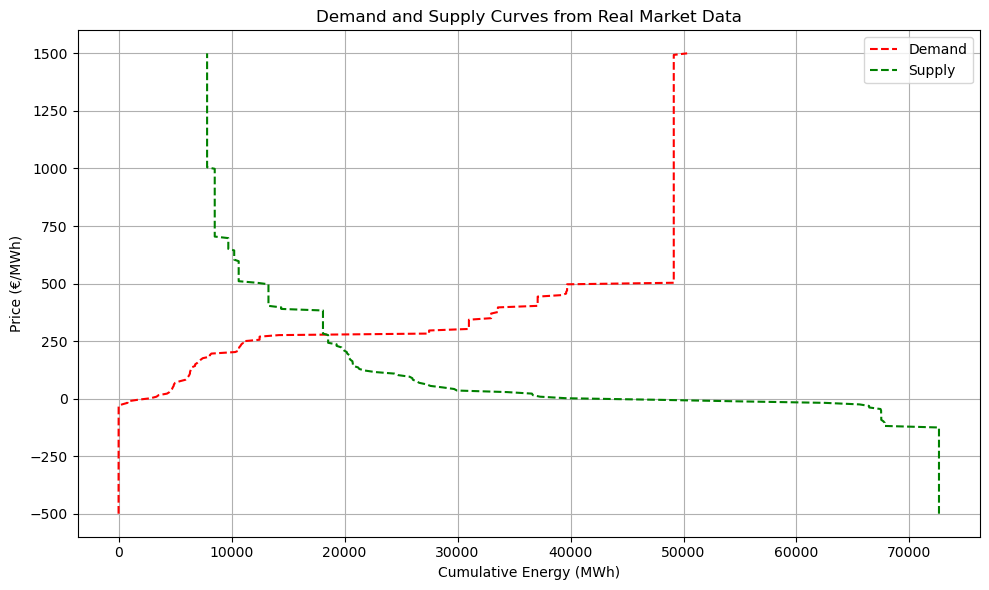

Demand price range: -499.0 - 1500.0
Supply price range: -500.0 - 3000.0
Used price_bounds: (-499.0, 1500.0)


In [46]:
rdc_points = compute_rdc_from_funcs(demand_func, supply_func, wf_offers, price_bounds)
discrete_blocks = discretize_rdc(rdc_points)

q_vals, p_vals = zip(*rdc_points)

plt.figure(figsize=(10,6))
price_range = np.linspace(price_bounds[0], price_bounds[1], 300)
plt.plot(demand_func(price_range), price_range, label='Demand', color='red', linestyle='--')
plt.plot(supply_func(price_range), price_range, label='Supply', color='green', linestyle='--')
plt.xlabel('Cumulative Energy (MWh)')
plt.ylabel('Price (€/MWh)')
plt.title('Demand and Supply Curves from Real Market Data')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Demand price range:", demand['price'].min(), "-", demand['price'].max())
print("Supply price range:", supply['price'].min(), "-", supply['price'].max())
print("Used price_bounds:", price_bounds)

In [3]:
# 공급 제안 중 체결된(C) 데이터 필터링
#df_offer = df[(df['ptype'] == 'V') & (df['OC'] == 'C')]
supply = df[(df['ptype'] == 'V')].copy()
# 가격 오름차순 정렬
supply = supply.sort_values(by='price',ascending=False)
# 누적 전력량 계산
supply['Cumulative Energy'] = supply['power'].cumsum()

In [4]:
demand = df[(df['ptype'] == 'C')].copy()
demand = demand.sort_values(by='price', ascending=True)
demand['Cumulative Energy'] = demand['power'].cumsum()


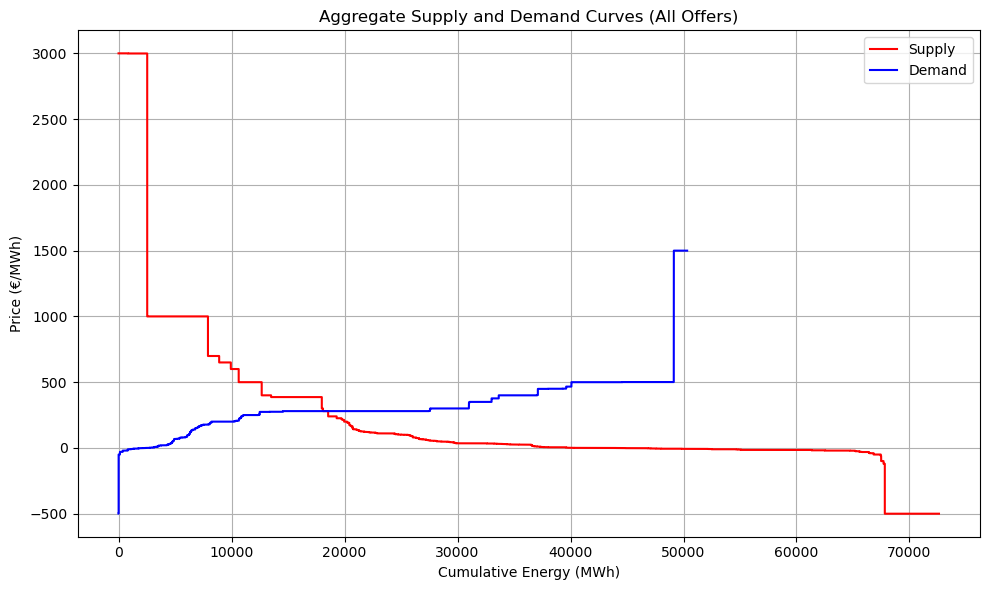

In [5]:
plt.figure(figsize=(10,6))
plt.step(supply['Cumulative Energy'], supply['price'], where='post', label='Supply', color='red')
plt.step(demand['Cumulative Energy'], demand['price'], where='post', label='Demand', color='blue')

plt.xlabel('Cumulative Energy (MWh)')
plt.ylabel('Price (€/MWh)')
plt.title('Aggregate Supply and Demand Curves (All Offers)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 곡선 생성
demand_vals = generate_demand_curve(price_grid, a_d, b_d)
supply_vals = generate_supply_curve(price_grid, c_s, d_s)

# WF offer grid
wf_offer_grid = np.linspace(0, 500, 30)

# RDC 계산 및 이산화
rdc_points = compute_rdc_from_curves(price_grid, demand_vals, supply_vals, wf_offer_grid)
discrete_blocks = discretize_rdc(rdc_points)

# === 5. 시각화 ===

q_vals, p_vals = zip(*rdc_points)

plt.figure(figsize=(10, 6))

# 곡선형 RDC
plt.plot(q_vals, p_vals, marker='o', color='blue', label='Residual Demand Curve')

# 이산화된 계단형 RDC
for q_ini, q_max, lambda_b in discrete_blocks:
    plt.hlines(lambda_b, q_ini, q_ini + q_max, colors='black', linewidth=2)
    plt.vlines(q_ini + q_max, lambda_b - 0.2, lambda_b + 0.2, colors='black', linewidth=1)

# 수요/공급 곡선
plt.plot(demand_vals, price_grid, color='red', linestyle='--', label='Demand Curve')
plt.plot(supply_vals, price_grid, color='green', linestyle='--', label='Supply Curve')

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Residual Demand Curve (with Discretized Blocks)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'df_offer' is not defined